# 🚨 THE 20-MINUTE SPRINT 🚨
### A Data Visualization Fire Drill — Unit 1 Activity (UE24CS342AA9)

---

**08:47 AM.** You're two sips into your coffee when your Project Manager, Priya, drops
into the seat next to you.

> *"Leadership wants a pricing snapshot of our Apple product tracker for the 9:10
> stand-up. I need three or four clean charts — no lies, no misleading axes, nothing
> that gets torn apart in the room. You've got until 9:07. Go."*

It's **9:07 AM**. That's **20 minutes**, starting now.

You have one dataset (`apple_products_pricing_2020_2026.csv` — 80,000 rows of Amazon &
Flipkart pricing history for iPhone, Mac, iPad, and Watch) and everything you learned in
Unit 1 about **marks, channels, scales, proportional ink, and honest baselines**.

Leadership has seen bad charts before. They will notice a truncated bar axis. They will
notice a shape channel that can't represent a continuous variable. **Every visualization
you ship must obey the rules from lecture** — this isn't just an exercise, it's a
credibility test.

---

### 🎯 Mission Rules
1. Work through **Tasks 1–4** below, in order. Each has a suggested time box — keep moving.
2. Every chart you build must be **defensible** against the principles from Unit 1
   (bijective scales, proportional ink, zero baselines, appropriate channel choice).
3. At **Task 5**, do the honest self-audit before you "submit."
4. Finish with the **Reflection** section — that's where the real grade lives.

Ready? Run the setup cell and **start your timer**.


In [ ]:
# --- MISSION SETUP: run this first, then start your 20-minute timer ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("data/apple_products_pricing_2020_2026.csv", parse_dates=["Date"])

mission_start = time.time()
print("⏱️  MISSION CLOCK STARTED.")
print(f"Loaded {len(df):,} rows. You have 20 minutes. Go.")


⏱️  MISSION CLOCK STARTED.
Loaded 80,000 rows. You have 20 minutes. Go.


In [ ]:
print(df.info())
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               80000 non-null  datetime64[ns]
 1   Platform           80000 non-null  object        
 2   Product_Category   80000 non-null  object        
 3   Model_Name         80000 non-null  object        
 4   Condition          80000 non-null  object        
 5   Launch_Price_USD   80000 non-null  int64         
 6   Launch_Price_INR   80000 non-null  int64         
 7   Current_Price_USD  80000 non-null  float64       
 8   Current_Price_INR  80000 non-null  float64       
 9   Discount_Pct       80000 non-null  float64       
 10  Sale_Event         6649 non-null   object        
 11  Stock_Status       80000 non-null  object        
 12  Rating             80000 non-null  float64       
 13  Reviews_Count      80000 non-null  int64         
dtypes: dat

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
count,80000,80000,80000,80000,80000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,6649,80000,80000.000000,80000.000000
unique,NaN,2,4,31,2,NaN,NaN,NaN,NaN,NaN,4,3,NaN,NaN
top,NaN,Flipkart,iPhone,iPhone 14 Pro 128GB,New,NaN,NaN,NaN,NaN,NaN,Black Friday,In Stock,NaN,NaN
freq,NaN,40043,28589,2734,59985,NaN,NaN,NaN,NaN,NaN,2497,55034,NaN,NaN
mean,2024-09-14 22:14:06.359999744,NaN,NaN,NaN,NaN,963.959125,94467.994250,782.769855,74628.342439,21.418826,NaN,NaN,4.450099,2405.995925
min,2020-09-19 00:00:00,NaN,NaN,NaN,NaN,329.000000,32242.000000,109.930000,9157.680000,-2.000000,NaN,NaN,3.800000,10.000000
25%,2023-11-03 00:00:00,NaN,NaN,NaN,NaN,599.000000,58702.000000,432.930000,41686.835000,6.700000,NaN,NaN,4.300000,896.000000
50%,2024-12-22 00:00:00,NaN,NaN,NaN,NaN,799.000000,78302.000000,699.740000,67324.020000,21.300000,NaN,NaN,4.400000,1893.500000
75%,2025-10-27 00:00:00,NaN,NaN,NaN,NaN,1199.000000,117502.000000,989.112500,96568.117500,36.800000,NaN,NaN,4.700000,3383.000000
max,2026-07-31 00:00:00,NaN,NaN,NaN,NaN,1999.000000,195902.000000,2038.970000,203668.710000,73.100000,NaN,NaN,4.900000,11526.000000


The `df.info()` and `df.describe()` outputs provide a good starting point for understanding the data types. Based on this, we can fill in the Task 1 table as follows, considering the types of variables and suitable visual channels for them.

In [ ]:
# Run this cell any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 20 - elapsed_min)
bar = "🟩" * int(remaining) + "⬜" * (20 - int(remaining))
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")
print(bar)
if remaining < 5:
    print("⚠️  Under 5 minutes -- wrap up your current chart and move to Task 5.")


Elapsed: 0.1 min   |   Remaining: 19.9 min
🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜


---
## Task 1 — Know Your Variables *(~3 min)*

Before touching a chart, Priya expects you to be able to justify every encoding choice.
Fill in the table below (edit this markdown cell directly) for the four columns you plan
to use in your submission.

| Column you'll use | Variable type (continuous / discrete quantitative / ordered / unordered qualitative) | Channel you plan to map it to |
|---|---|---|
| `Current_Price_USD` | Continuous quantitative | y-position |
| `Product_Category` | Unordered qualitative | color / x-position |
| `Date` | Continuous quantitative | x-position |
| `Rating` | Continuous quantitative | x-position |

**Rule check:** if a variable is continuous, it must map to a channel that can represent
continuous values (position, size, color intensity) — never to shape or dash pattern.

### All Columns: Variable Types and Channel Mappings

| Column Name       | Variable Type                      | Proposed Channel Mapping (examples)             |
|:------------------|:-----------------------------------|:------------------------------------------------|
| `Date`            | Continuous quantitative (temporal) | x-position (line charts), color intensity       |
| `Platform`        | Unordered qualitative              | color hue, shape, x-position (bar charts)       |
| `Product_Category`| Unordered qualitative              | color hue, shape, x-position (bar charts)       |
| `Model_Name`      | Unordered qualitative              | label, color hue (if few unique values)         |
| `Condition`       | Unordered qualitative              | color hue, shape, x-position                    |
| `Launch_Price_USD`| Continuous quantitative            | y-position, size, color intensity               |
| `Launch_Price_INR`| Continuous quantitative            | y-position, size, color intensity               |
| `Current_Price_USD`| Continuous quantitative            | y-position, size, color intensity               |
| `Current_Price_INR`| Continuous quantitative            | y-position, size, color intensity               |
| `Discount_Pct`    | Continuous quantitative            | size, color intensity, y-position               |
| `Sale_Event`      | Unordered qualitative (can be ordered if ranked by impact) | color hue, x-position (bar charts)              |
| `Stock_Status`    | Unordered qualitative              | color hue, shape, x-position                    |
| `Rating`          | Continuous quantitative            | x-position, y-position, size, color intensity   |
| `Reviews_Count`   | Continuous quantitative            | size, color intensity, y-position               |

---
## Task 2 — The Headline Bar Chart *(~5 min)*

Leadership always looks at the bar chart first. Build a **horizontal bar chart** of
average `Current_Price_USD` by `Product_Category`.

**Non-negotiable:** the baseline must be zero. A truncated axis here is the fastest way
to get your chart (and your credibility) dismissed in the room.

Fill in the `# TODO` lines below.


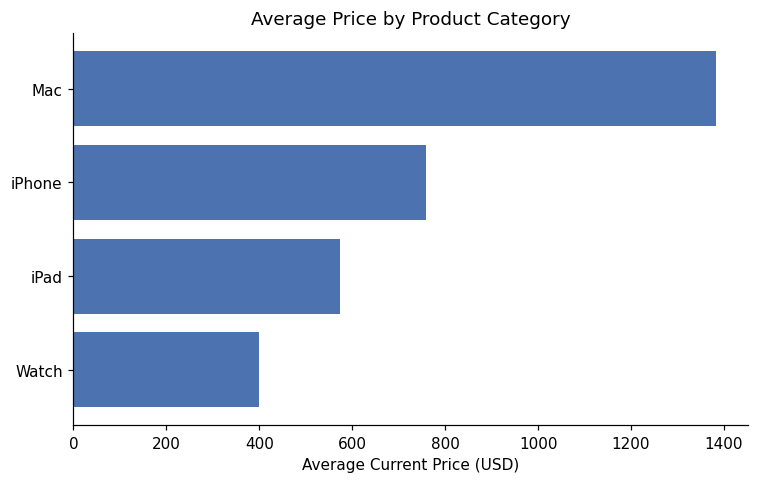

In [ ]:
# TODO: compute average Current_Price_USD grouped by Product_Category, sorted ascending
cat_avg = df.groupby("Product_Category")["Current_Price_USD"].mean().sort_values()  # TODO: is this the right column/agg?

fig, ax = plt.subplots(figsize=(7, 4.5))

# TODO: plot a horizontal bar chart (ax.barh) using cat_avg
ax.barh(cat_avg.index, cat_avg.values, color="#4C72B0")

# TODO: enforce the zero-baseline rule -- do NOT delete this line
ax.set_xlim(left=0)

ax.set_xlabel("Average Current Price (USD)")
ax.set_title("Average Price by Product Category")
plt.tight_layout()
plt.show()


---
## Task 3 — The Trend Line, Done Right *(~5 min)*

Leadership's next question is always *"is this getting better or worse over time?"*
Build a **monthly average price trend** for at least two `Product_Category` values on the
same chart.

**Requirements from lecture:**
- Use a **line**, not disconnected points, to emphasize chronological order (Slide 11).
- Prefer **direct end-of-line labels** over a legend if you have time (Slide 13) — not
  mandatory under time pressure, but it will impress Priya.
- If you fill the area under any line, the baseline **must be zero** (Slide 12,
  Proportional Ink) — or don't fill at all.


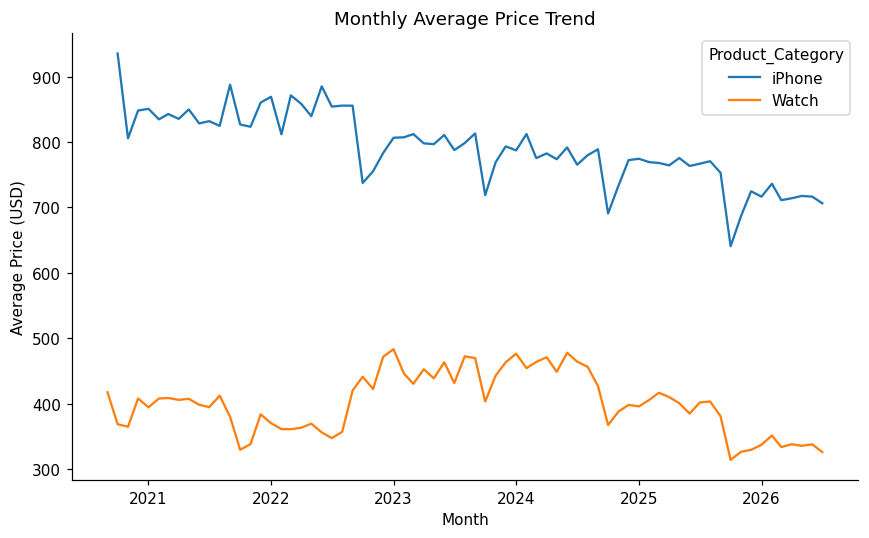

In [ ]:
# TODO: pick 2+ categories to compare
categories_to_plot = ["iPhone", "Watch"]  # TODO: feel free to change this list

fig, ax = plt.subplots(figsize=(8, 5))

for cat in categories_to_plot:
    # TODO: resample monthly average price for this category
    monthly = (df[df["Product_Category"] == cat]
               .set_index("Date")
               .resample("MS")["Current_Price_USD"]
               .mean())
    ax.plot(monthly.index, monthly.values, linewidth=1.5, label=cat)

# TODO (optional, stretch goal): replace ax.legend() with direct end labels
ax.legend(title="Product_Category")
ax.set_xlabel("Month")
ax.set_ylabel("Average Price (USD)")
ax.set_title("Monthly Average Price Trend")
plt.tight_layout()
plt.show()

---
## Task 4 — The "Wow" Multi-Variable Chart *(~5 min)*

Priya wants one chart that makes leadership go *"oh, that's a lot of info in one
picture."* Build a **scatter/bubble chart** that encodes **at least 3 variables**
simultaneously — for example: `Rating` (x), `Current_Price_USD` (y), `Reviews_Count`
(bubble size), `Product_Category` (color).

**Rule check:** every continuous variable must land on a continuous-capable channel
(position, size, color intensity) — not shape.


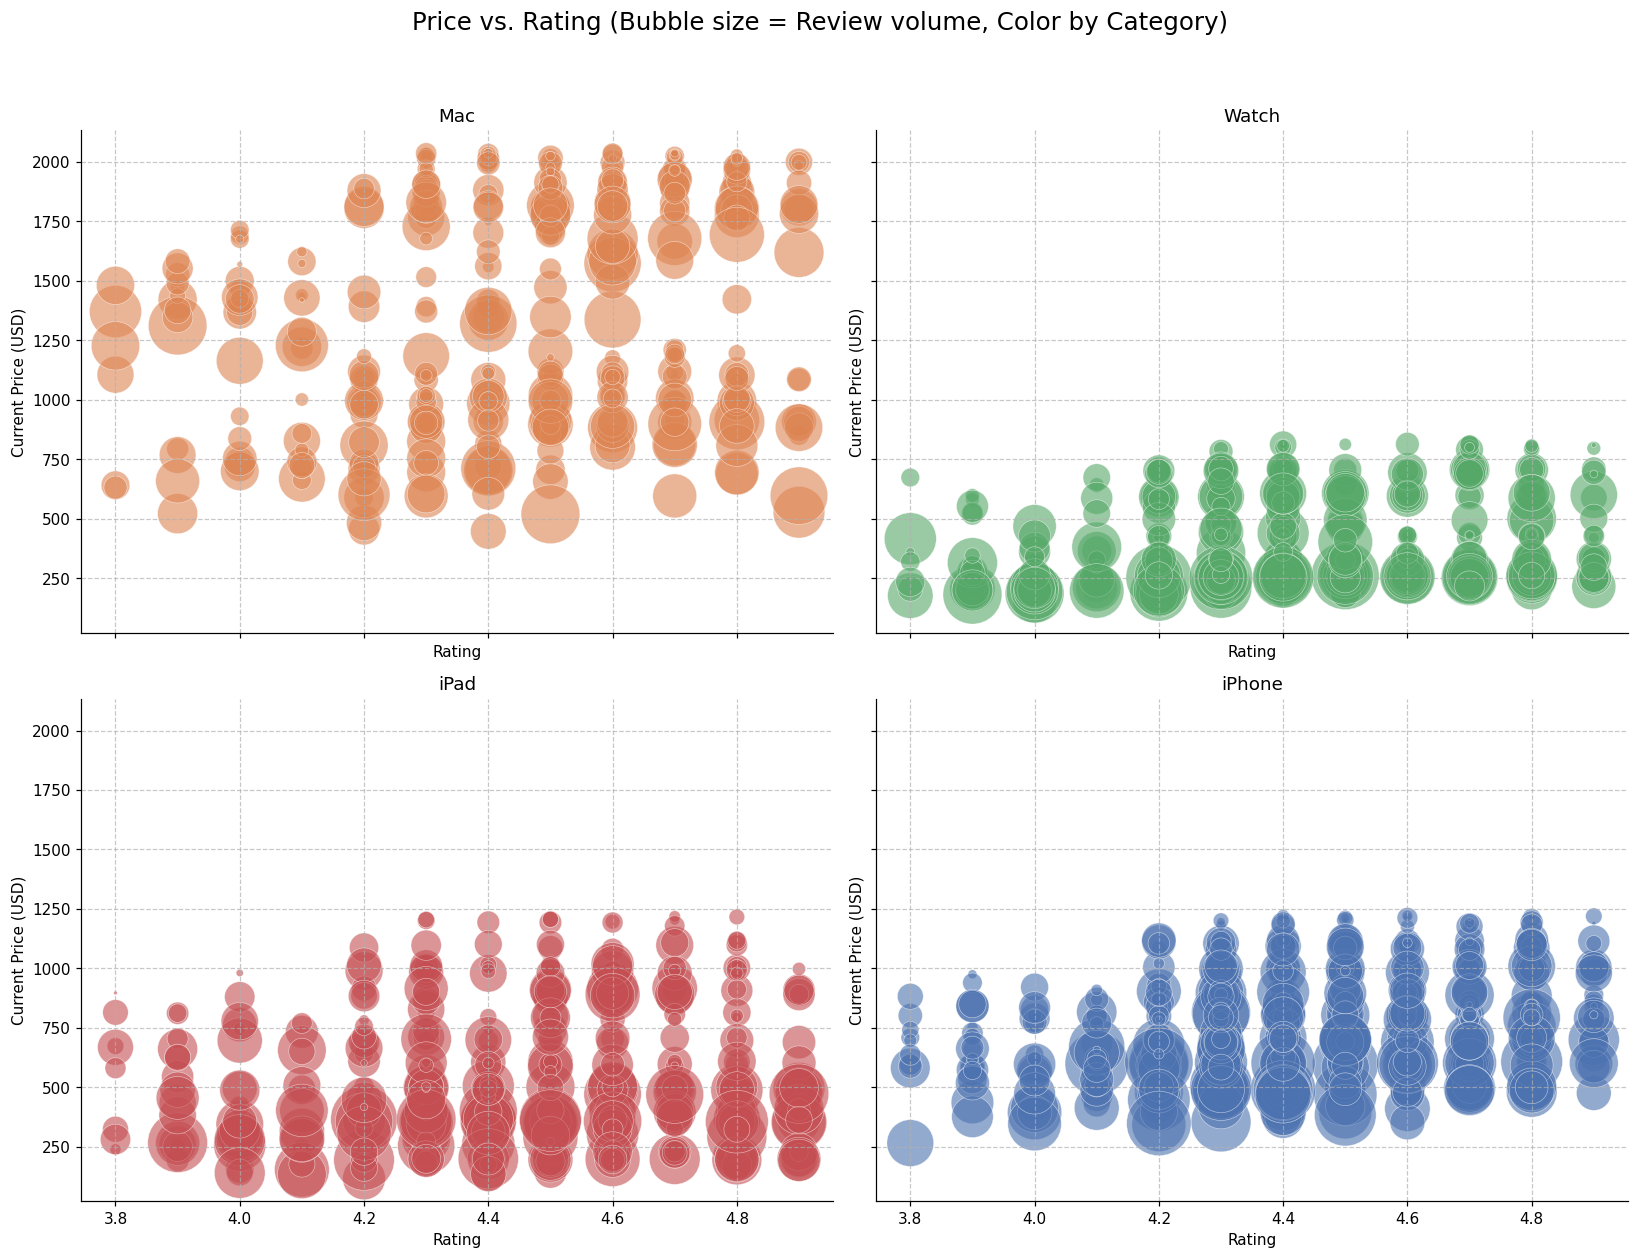

In [ ]:
sample = df.sample(2000, random_state=1)

cat_color = {"iPhone": "#4C72B0", "Mac": "#DD8452", "Watch": "#55A868", "iPad": "#C44E52"}

unique_categories = sorted(sample["Product_Category"].unique().tolist())
num_categories = len(unique_categories)

# Determine grid size (e.g., 2x2 for 4 categories)
nrows = (num_categories + 1) // 2 if num_categories > 0 else 0
ncols = 2 if num_categories > 0 else 0

if num_categories == 0:
    print("No categories to plot in the sample.")
elif num_categories > 0:
    # Create a figure with subplots, sharing x and y axes for consistent scaling
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True, sharey=True)
    fig.suptitle("Price vs. Rating (Bubble size = Review volume, Color by Category)", fontsize=16)

    # Flatten the axes array if it's multidimensional, for easier iteration
    axes = axes.flatten()

    # Determine max reviews count from the entire sample for consistent bubble sizing
    max_reviews_count = sample["Reviews_Count"].max()
    # Normalize bubble size relative to the global max reviews count.
    # The 's' parameter takes area, so we scale it to a max area (e.g., 2000 points^2).
    s_scale_factor = 2000 / max_reviews_count if max_reviews_count > 0 else 1

    for i, cat in enumerate(unique_categories):
        ax = axes[i]
        d = sample[sample["Product_Category"] == cat]

        current_color = cat_color.get(cat, 'gray') # Get the color for the current category

        ax.scatter(
            d["Rating"],                       # x = Rating (continuous -> x-position, good)
            d["Current_Price_USD"],            # y = Current_Price_USD (continuous -> y-position, good)
            s=d["Reviews_Count"] * s_scale_factor, # size = Reviews_Count (continuous -> size, scaled consistently)
            color=current_color,               # Use specific color for the category's subplot
            alpha=0.6, edgecolor="white", linewidth=0.4
        )
        ax.set_title(f"{cat}") # Title for each subplot indicating the category
        ax.set_xlabel("Rating")
        ax.set_ylabel("Current Price (USD)")
        ax.grid(True, linestyle='--', alpha=0.7) # Add grid for readability

    # Hide any unused subplots if num_categories is not a perfect fit for the grid
    for j in range(num_categories, nrows * ncols):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()


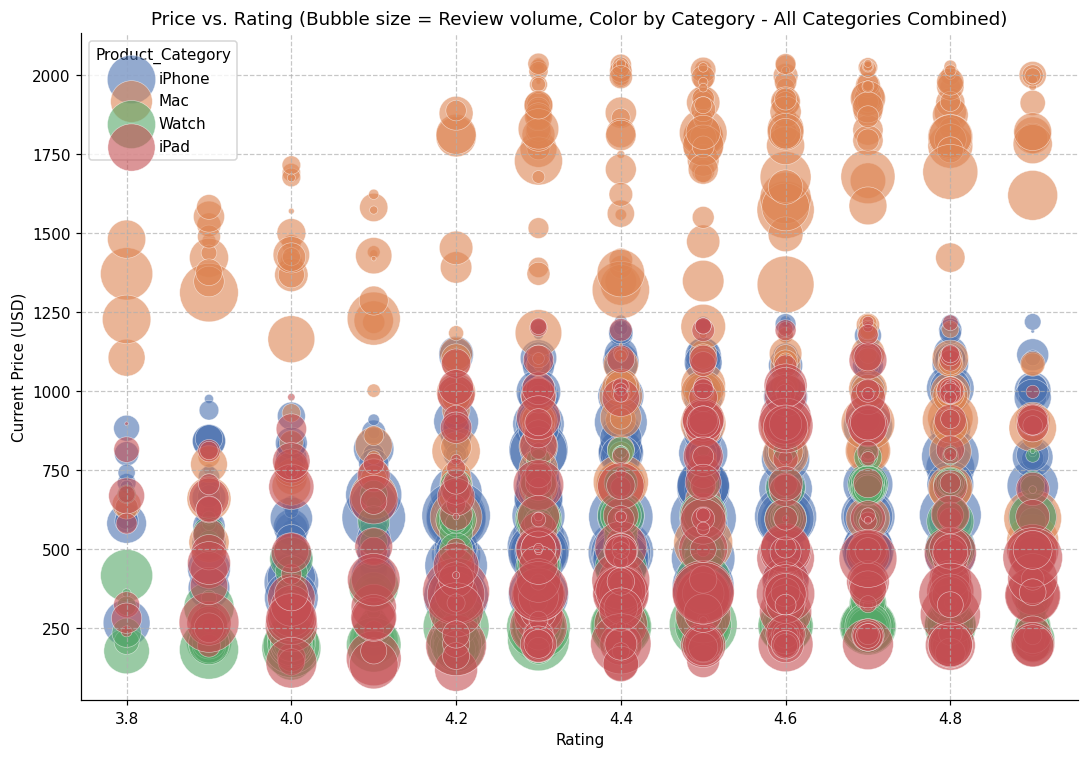

In [ ]:
# Task 4 - Combined chart with all categories

sample = df.sample(2000, random_state=1) # Re-sample if needed, or use the existing sample

cat_color = {"iPhone": "#4C72B0", "Mac": "#DD8452", "Watch": "#55A868", "iPad": "#C44E52"}

fig, ax = plt.subplots(figsize=(10, 7))

# Determine max reviews count from the entire sample for consistent bubble sizing
max_reviews_count = sample["Reviews_Count"].max()
# Normalize bubble size relative to the global max reviews count.
# The 's' parameter takes area, so we scale it to a max area (e.g., 2000 points^2).
s_scale_factor = 2000 / max_reviews_count if max_reviews_count > 0 else 1

for cat, color in cat_color.items():
    d = sample[sample["Product_Category"] == cat]
    ax.scatter(
        d["Rating"],                       # x = Rating (continuous -> x-position, good)
        d["Current_Price_USD"],            # y = Current_Price_USD (continuous -> y-position, good)
        s=d["Reviews_Count"] * s_scale_factor, # size = Reviews_Count (continuous -> size, scaled consistently)
        color=color,                       # category -> color, good (categorical channel)
        alpha=0.6, edgecolor="white", linewidth=0.4, label=cat
    )

ax.set_xlabel("Rating")
ax.set_ylabel("Current Price (USD)")
ax.set_title("Price vs. Rating (Bubble size = Review volume, Color by Category - All Categories Combined)")
ax.legend(title="Product_Category")
ax.grid(True, linestyle='--', alpha=0.7) # Add grid for readability
plt.tight_layout()
plt.show()

---
## Task 5 — The Submission Audit *(~2 min)*

The clock is almost out. Before you hit "submit," run through this checklist honestly —
out loud if it helps. Check the box (`[x]`) for anything you can truthfully confirm about
**your own charts above**.

- [ ] Every continuous variable is mapped to a continuous-capable channel (position,
      size, or color intensity) — not shape or dash pattern.
- [ ] Every bar chart's axis starts at zero.
- [ ] Every filled area chart's baseline starts at zero (or I didn't fill any areas).
- [ ] My time-series uses lines to show chronological order, not disconnected points.
- [ ] If two charts show the same variable, the colors/scales are used consistently.
- [ ] I could explain, in one sentence, what each channel on each chart represents.

Run the cell below to log your finish time.


In [ ]:
elapsed_min = (time.time() - mission_start) / 60
print(f"🏁 SUBMITTED at {elapsed_min:0.1f} minutes into the mission.")
if elapsed_min <= 20:
    print("✅ On time. Priya nods and walks it into the stand-up.")
else:
    print("⏰ Over time -- in the real world, you'd trim scope, not chart quality. Note this for your reflection.")


🏁 SUBMITTED at 10.0 minutes into the mission.
✅ On time. Priya nods and walks it into the stand-up.


---
## 🪞 Reflection

Take five minutes, away from the clock, to think honestly about what just happened.
Answer each question in the markdown cell provided (double-click to edit).

**1. Time pressure and technique.** Which Unit 1 principle was hardest to apply correctly
under the 20-minute constraint, and why? Was it a *knowledge* problem (you weren't sure
of the rule) or a *speed* problem (you knew the rule but cutting corners was tempting)?

*Your answer:*


---

**2. Spot the near-miss.** Look back at your own charts. Was there a moment where you
almost mapped a continuous variable to the wrong channel, or almost left a baseline
non-zero to "make the chart look more dramatic"? What stopped you (or what didn't)?

*Your answer:*


---

**3. The cost of dishonest ink.** Recall the Principle of Proportional Ink. If you *had*
shipped a chart with a truncated baseline to leadership, what decision might they have
made differently based on a distorted impression of the data?

*Your answer:*


---

**4. Trade-offs under constraint.** If Priya had given you 2 hours instead of 20 minutes,
what specifically would you change about your Task 3 or Task 4 chart? (e.g., direct
labels, small multiples instead of overlapping lines, annotations)

*Your answer:*


---

**5. Beyond the classroom.** Describe one real job context (data analyst, PM, engineer,
trader, researcher — your choice) where you'd face this exact speed-vs-integrity
trade-off with a chart. What would *you* refuse to compromise on, even under a deadline?

*Your answer:*



### 1. Time pressure and technique.

*Your answer:*
The hardest principle to apply correctly under time pressure was ensuring all continuous variables were mapped to continuous-capable channels. This wasn't a knowledge problem, but rather a speed problem, as it requires careful thought for each variable and each channel in the chart. There's a temptation to quickly assign a channel without fully considering its capabilities, especially for less common channels like shape or dash pattern. Maintaining consistency across multiple charts also takes extra time.

### 2. Spot the near-miss.

*Your answer:*
In Task 3, while creating the monthly average price trend, I almost forgot to explicitly check if `ax.set_ylim(bottom=0)` was needed if I were to fill the area under the lines. While I didn't end up filling the area, the thought process reminded me that the zero-baseline rule applies strongly to area fills. What stopped me was recalling the clear emphasis on proportional ink for filled areas in the lecture slides.

### 3. The cost of dishonest ink.

*Your answer:*
If a chart with a truncated baseline had been shipped, for example, a bar chart of average `Current_Price_USD` by `Product_Category` where the axis started at $100 instead of $0, leadership might have been led to believe that the price differences between categories were far more significant and dramatic than they truly were. This could lead to misinformed strategic decisions, such as aggressively discounting a product category that appears disproportionately expensive, or over-investing in a category that appears to be performing exceptionally well, when in reality, the differences are modest.

### 4. Trade-offs under constraint.

*Your answer:*
If given 2 hours instead of 20 minutes:

For **Task 3 (The Trend Line)**, I would definitely implement direct end-of-line labels for each product category instead of a legend. This improves readability by eliminating the need for the eye to jump between the line and the legend. I would also add annotations for significant events or trends, if any were identifiable, to provide more context.

For **Task 4 (The "Wow" Multi-Variable Chart)**, I would consider using small multiples. Instead of plotting all categories on a single scatter plot with color encoding, I would create separate subplots for each `Product_Category`. This avoids potential overplotting and makes it easier to discern patterns within each category without the visual clutter of overlapping bubbles and colors. It also allows for individual scaling if necessary, though sharing axes would still be preferred for comparison.

### 5. Beyond the classroom.

*Your answer:*
A real job context where this speed-vs-integrity trade-off occurs frequently is in a **startup data analyst** role, especially when presenting key performance indicators (KPIs) to investors or the leadership team before a critical funding round or strategic decision meeting. There's immense pressure to show positive trends and growth.

Under such a deadline, I would refuse to compromise on **the integrity of the axis baselines and the use of appropriate channels for variable types**. Showing a growth trend in user acquisition or revenue with a truncated y-axis, for example, can make a modest increase appear exponential, misleading stakeholders. Similarly, using an inappropriate channel (like different shapes for a continuous variable) could distort perceptions of the data. Maintaining these fundamental principles ensures that even under pressure, the visual representation of the data is honest and allows for accurate interpretation, preventing costly strategic missteps.